# Simulated IRFs from True VAR Model

This code creates simulated time series data where the underlying process is a VAR model, in order to asses the accuracy of LPs & SPLs when the true process is follows a VAR structure. The underlying VAR model uses randomly generated coefficients and is of order $O$ with $V$ variables. Since all variables are ex-ante identical, only a shock to variable 1 will be considered and only the IRFs for the first three variables will be examined.

In [132]:
# append the path of the parent directory to import slp modules
import sys
sys.path.append("..")

# import packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.api import VAR

# import slp module
from slp.estimators import SmoothLocalProjections

In [133]:
# set parameters
q = 20 # number of periods for IRF
T = 100 # number of periods for simulated data
O = 4 # VAR order
V = 3 # number of variables in VAR

np.random.seed(3891) # set seed for reproducibility

In [134]:
# IRF plotting function
def plot_irf(data, title):
    varnames = data.columns
    plt.figure(figsize=(12, 8))
    for i in range(3):
        plt.subplot(2, 3, i+1)
        plt.plot(data[varnames[i]])
        plt.title(f'var1 -> var{i+1}')
        plt.xlabel('Quarters')
        plt.ylabel('Response')
        plt.axhline(0, color='black', linestyle='dashed')
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

### Generating observed data

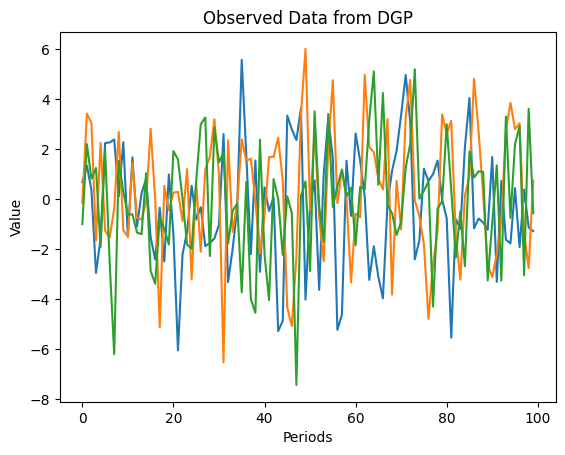

In [135]:
# simulate data from VAR process based on parameters and random coefficients
def VAR_data(V, O, T):
    A = np.random.uniform(low = -0.25, high = 0.25, size=(O, V, V)) # coefficients restricted to prevent explosive processes
    I = np.ones((O, 3)) # initial periods of data

    observed_data = np.zeros((T+O, V))
    for t in range(0, T+O):
        if t < O:
            observed_data[t] = I[t]
        else:
            for o in range(1, O+1):
                observed_data[t] += A[o-1] @ observed_data[t-o, :] + np.random.normal(size = V) # VAR process
    observed_data = pd.DataFrame(observed_data, columns=[f'var{i}' for i in range(1, V+1)])

    observed_data = observed_data.drop(index=range(O)) # drop initial periods of data
    return observed_data.reset_index(drop = True), A

observed_data, A = VAR_data(V,O,T) # save the observed data and the matrices used to generate it (needed for true IRF)

# plot observed time series
plt.plot(observed_data)
plt.title("Observed Data from DGP")
plt.xlabel("Periods")
plt.ylabel("Value")
plt.show()

### Generating the true IRFs

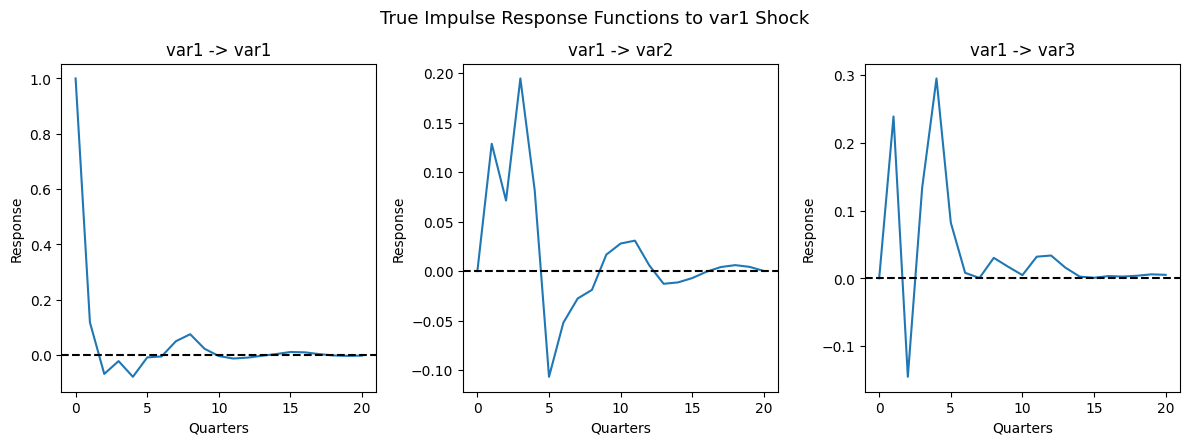

In [136]:
# true IRF from for a unit var1 shock
# this is the true IRF that the econometrician is trying to estimate from observed data
def true(V, O, q, A):
    shock = np.zeros(V)
    shock[0] = 1 # shock variable 1
    irf = np.zeros((q+1, V))
    for t in range(q+1):
        if t == 0:
            irf[t] = shock
        else:
            for o in range(1, O+1):
                if t-o >= 0:
                    irf[t] += A[o-1] @ irf[t-o]

    return pd.DataFrame(irf, columns=[f'var{j}_shock1' for j in range(1, V+1)])

true_irf = true(V,O,q,A)

# plot the true IRFs to a unit shock in variable 1
plot_irf(true_irf, 'True Impulse Response Functions to var1 Shock')

### Estimating the IRFs using VAR

AIC optimal lags: 4


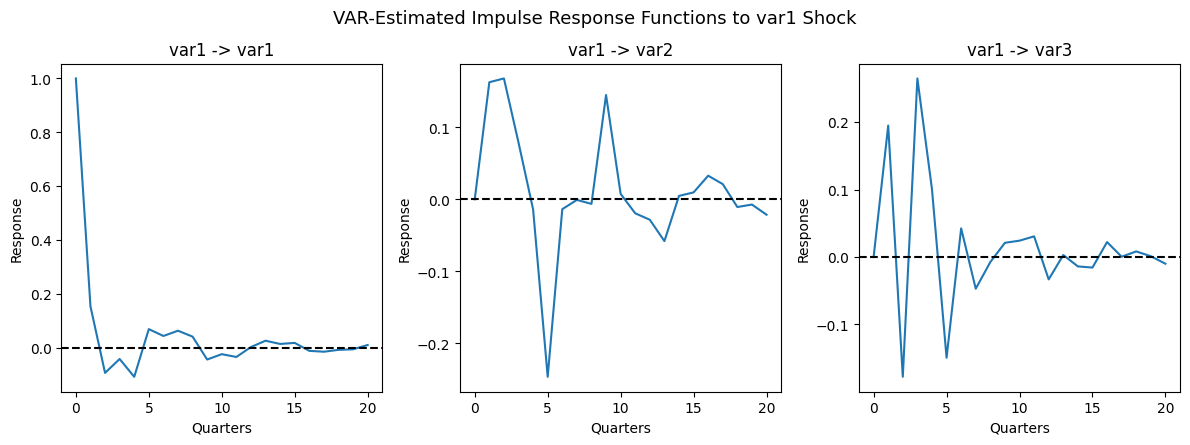

In [137]:
# VAR estimation of IRFs
model = VAR(observed_data)
opt_lags = model.select_order(maxlags=10).aic
results = model.fit(opt_lags)
irfs = results.irf(periods=q).irfs
var = pd.DataFrame(irfs[:,:,0])

print("AIC optimal lags:", opt_lags) # optimal lags from AIC - used for VAR, LP, and SLP estimation

plot_irf(var, 'VAR-Estimated Impulse Response Functions to var1 Shock')

### Estimating the IRFs using local projections

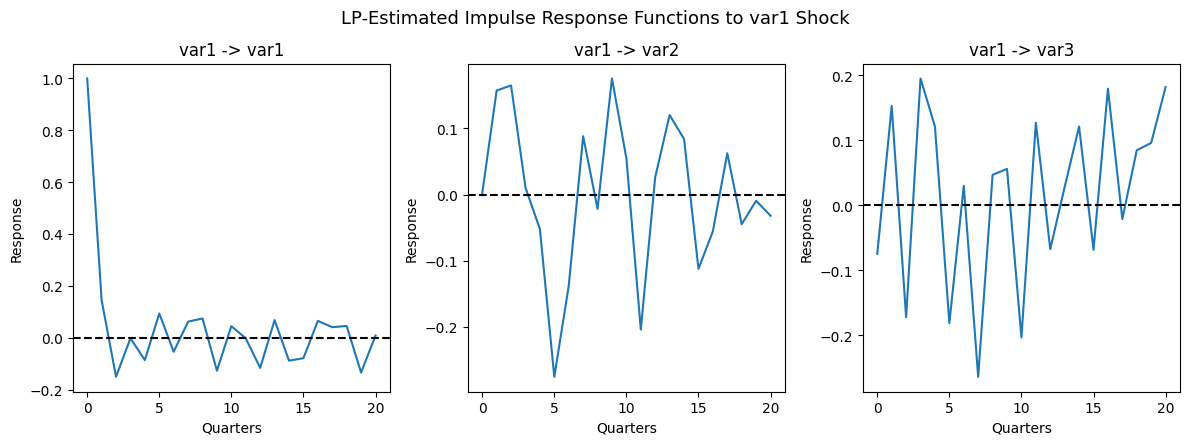

In [138]:
# estimating IRF using LPs on observed data
LP_model = SmoothLocalProjections(observed_data, "var1", None, True, opt_lags, q)
LP = pd.DataFrame(LP_model.LP().beta)

plot_irf(LP, 'LP-Estimated Impulse Response Functions to var1 Shock')

### Estimating the IRFs using smooth local projections

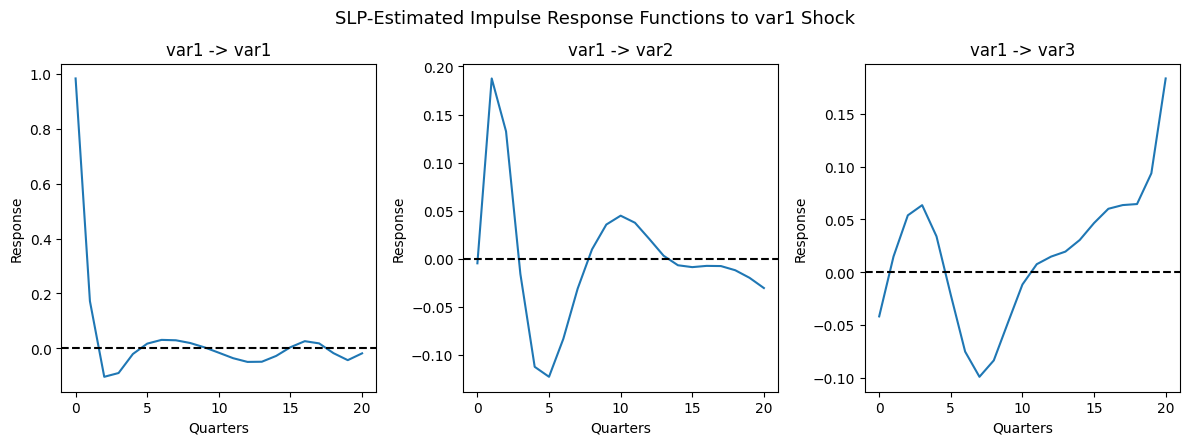

In [139]:
# estimating IRF using SLPs on observed data
SLP_model = SmoothLocalProjections(observed_data, "var1", None, True, opt_lags, q)
SLP = pd.DataFrame(SLP_model.SLP().beta)

plot_irf(SLP, 'SLP-Estimated Impulse Response Functions to var1 Shock')

### Discussion
One way of comparing the different estimates is by measuring the mean squared error (MSE) of the estimated IRFs from the true IRF. In order to ensure that the result is not due to the specific pattern of shocks drawn this should be average over multiple iterations. From the below calculations it is clear that VARs have an advantage when the underlying DGP follows a vector autoregressive process. Examining the plots suggests that a weakness of the LP and SLP approaches is failing to capture the lack of simultaneity in the true IRF: this DGP restricts a shock to var1 from affecting the other variables until one period later. LP and SLP estimations can also fail to capture the IRF diminishing to zero.

In [140]:
# Calculating the average mean squared error (MSE) over 50 simulations
var_MSE = np.zeros(50)
LP_MSE = var_MSE.copy()
SLP_MSE = var_MSE.copy()

i = 0
while i < 50:
    observed_data, A = VAR_data(V,O,T)
    true_irf = true(V,O,q,A)
    
    model = VAR(observed_data)
    opt_lags = model.select_order(maxlags=10).aic

    if opt_lags == 0:
        continue # sometimes the DGP will result in zero lags optimal, so skip this iteration since it breaks estimation
    
    results = model.fit(opt_lags)
    irfs = results.irf(periods=q).irfs
    var = pd.DataFrame(irfs[:,:,0])

    LP_model = SmoothLocalProjections(observed_data, "var1", None, True, opt_lags, q)
    LP = pd.DataFrame(LP_model.LP().beta)
    SLP = pd.DataFrame(LP_model.SLP().beta)

    var_MSE[i] = np.mean((true_irf.values - var.values)**2)
    LP_MSE[i] = np.mean((true_irf.values - LP.values)**2)
    SLP_MSE[i] = np.mean((true_irf.values - SLP.values)**2)

    i += 1

avg_var_MSE = np.mean(var_MSE)
avg_LP_MSE = np.mean(LP_MSE)
avg_SLP_MSE = np.mean(SLP_MSE)

print(f"Average MSE of VAR IRFs over 50 simulations: {avg_var_MSE:.5f}")
print(f"Average MSE of LP IRFs over 50 simulations: {avg_LP_MSE:.5f}")
print(f"Average MSE of SLP IRFs over 50 simulations: {avg_SLP_MSE:.5f}")

Average MSE of VAR IRFs over 50 simulations: 0.00391
Average MSE of LP IRFs over 50 simulations: 0.01789
Average MSE of SLP IRFs over 50 simulations: 0.01115
